# 02 Model preparation

## Daten laden


In [1]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("../data/raw")

measures = pd.read_csv(DATA_DIR / "measures.csv", sep=";", decimal=",")
to_predict = pd.read_csv(DATA_DIR / "to_predict.csv", sep=";", decimal=",")

print("Measures:", measures.shape)
print("To predict:", to_predict.shape)

Measures: (7352, 563)
To predict: (2947, 562)


## Subject-Spalte prüfen

In [2]:
print("Subject dtype in measures:", measures["subject"].dtype)
print("Subject dtype in to_predict:", to_predict["subject"].dtype)

print("\nSubjects in measures:")
print([int(s) for s in sorted(measures["subject"].unique())])

print("\nSubjects in to_predict:")
print([int(s) for s in sorted(to_predict["subject"].unique())])

Subject dtype in measures: float64
Subject dtype in to_predict: int64

Subjects in measures:
[1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26, 27, 28, 29, 30]

Subjects in to_predict:
[2, 4, 9, 10, 12, 13, 18, 20, 24]


## Train/Test-Split nach Subjects

In [3]:
test_subjects = [27, 28, 29, 30]

train_data = measures[~measures["subject"].isin(test_subjects)].copy()
test_data = measures[measures["subject"].isin(test_subjects)].copy()

print("Train data:", train_data.shape)
print("Test data:", test_data.shape)

print("\nTrain subjects:")
print([int(s) for s in sorted(train_data["subject"].unique())])

print("\nTest subjects:")
print([int(s) for s in sorted(test_data["subject"].unique())])

Train data: (5867, 563)
Test data: (1485, 563)

Train subjects:
[1, 3, 5, 6, 7, 8, 11, 14, 15, 16, 17, 19, 21, 22, 23, 25, 26]

Test subjects:
[27, 28, 29, 30]


## Split prüfen

In [4]:
train_subjects = set(train_data["subject"].unique())
test_subjects_set = set(test_data["subject"].unique())

overlap = train_subjects.intersection(test_subjects_set)

required_train_subjects = {1, 3, 5, 6}

print("Überschneidungen zwischen Train und Test:", overlap)
print("Pflicht-Trainingssubjekte vorhanden:", required_train_subjects.issubset(train_subjects))

Überschneidungen zwischen Train und Test: set()
Pflicht-Trainingssubjekte vorhanden: True


## Features und Zielvariable festlegen

In [5]:
target_col = "activity"
group_col = "subject"

feature_cols = [col for col in measures.columns if col not in [target_col, group_col]]

X_train = train_data[feature_cols]
y_train = train_data[target_col]
groups_train = train_data[group_col]

X_test = test_data[feature_cols]
y_test = test_data[target_col]

X_unseen = to_predict[feature_cols]

print("Anzahl Feature-Spalten:", len(feature_cols))

print("\nX_train:", X_train.shape)
print("y_train:", y_train.shape)
print("groups_train:", groups_train.shape)

print("\nX_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nX_unseen:", X_unseen.shape)

Anzahl Feature-Spalten: 561

X_train: (5867, 561)
y_train: (5867,)
groups_train: (5867,)

X_test: (1485, 561)
y_test: (1485,)

X_unseen: (2947, 561)


## Feature-Spalten prüfen

In [6]:
same_features = (
    list(X_train.columns) == list(X_test.columns) == list(X_unseen.columns)
)

print("Gleiche Features in allen Datensätzen:", same_features)

Gleiche Features in allen Datensätzen: True


## Vorbereitete Daten speichern

In [7]:
PROCESSED_DIR = Path("../data/processed")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

train_data.to_csv(PROCESSED_DIR / "train_data.csv", index=False)
test_data.to_csv(PROCESSED_DIR / "test_data.csv", index=False)

with open(PROCESSED_DIR / "feature_columns.txt", "w", encoding="utf-8") as f:
    for col in feature_cols:
        f.write(col + "\n")

print("Gespeichert:")
print(PROCESSED_DIR / "train_data.csv")
print(PROCESSED_DIR / "test_data.csv")
print(PROCESSED_DIR / "feature_columns.txt")

Gespeichert:
..\data\processed\train_data.csv
..\data\processed\test_data.csv
..\data\processed\feature_columns.txt


## Explorative Analyse und erste Visualisierungen

In [8]:
activity_distribution = pd.DataFrame({
    "train_count": train_data["activity"].value_counts().sort_index(),
    "train_proportion": train_data["activity"].value_counts(normalize=True).sort_index(),
    "test_count": test_data["activity"].value_counts().sort_index(),
    "test_proportion": test_data["activity"].value_counts(normalize=True).sort_index()
})

activity_distribution["train_proportion"] = activity_distribution["train_proportion"].round(3)
activity_distribution["test_proportion"] = activity_distribution["test_proportion"].round(3)

activity_distribution

,train_count,train_proportion,test_count,test_proportion
activity,,,,
LAYING,1114,0.190,293,0.197
SITTING,1022,0.174,264,0.178
STANDING,1091,0.186,283,0.191
WALKING,997,0.170,229,0.154
WALKING_DOWNSTAIRS,786,0.134,200,0.135
WALKING_UPSTAIRS,857,0.146,216,0.145


## Ergebnisse als Tabelle speichern

In [9]:
RESULTS_TABLE_DIR = Path("../results/tables")
RESULTS_TABLE_DIR.mkdir(parents=True, exist_ok=True)

activity_distribution.to_csv(
    RESULTS_TABLE_DIR / "activity_distribution_train_test.csv",
    index=True
)

print("Gespeichert:", RESULTS_TABLE_DIR / "activity_distribution_train_test.csv")

Gespeichert: ..\results\tables\activity_distribution_train_test.csv


## Klassenverteilung als Grafik speichern

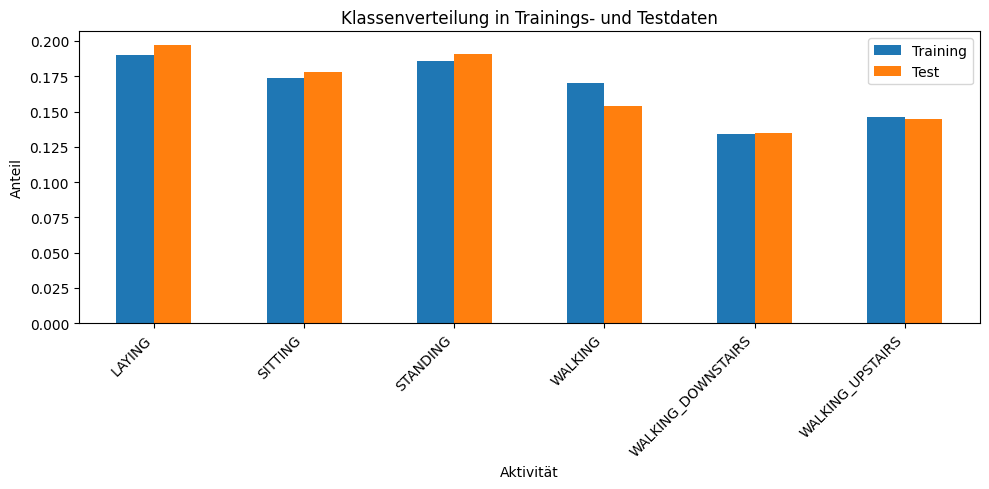

In [10]:
import matplotlib.pyplot as plt

FIGURE_DIR = Path("../results/figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

ax = activity_distribution[["train_proportion", "test_proportion"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Klassenverteilung in Trainings- und Testdaten")
plt.xlabel("Aktivität")
plt.ylabel("Anteil")
plt.xticks(rotation=45, ha="right")
plt.legend(["Training", "Test"])
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "class_distribution_train_test.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Messfenster pro Subject visualisieren

In [11]:
subject_counts = measures["subject"].value_counts().sort_index()

subject_counts

subject
1.0     347
3.0     341
5.0     302
6.0     325
7.0     308
8.0     281
11.0    316
14.0    323
15.0    328
16.0    366
17.0    368
19.0    360
21.0    408
22.0    321
23.0    372
25.0    409
26.0    392
27.0    376
28.0    382
29.0    344
30.0    383
Name: count, dtype: int64

## Messfenster-Grafik speichern

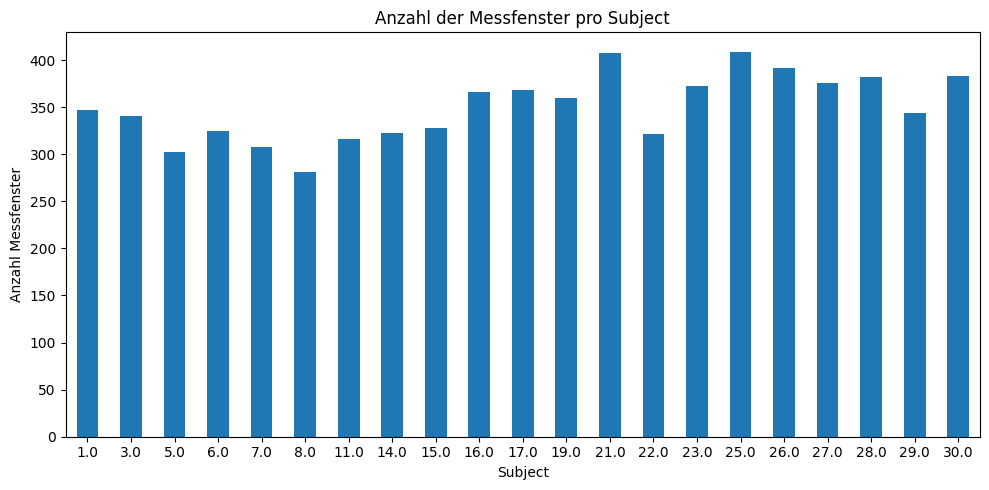

In [12]:
ax = subject_counts.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Anzahl der Messfenster pro Subject")
plt.xlabel("Subject")
plt.ylabel("Anzahl Messfenster")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "measurement_windows_per_subject.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()